# Chapter 1 — Notebook 2: Event loops with `awkward`

**Goals**

- Understand jagged (variable-length) arrays of leptons and jets.
- Apply selection masks event-by-event.
- Combine per-event scalars (`met`) with per-object jagged branches (`jet_pt`).

In [1]:
%matplotlib inline
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from topmass import io, kinematics, selection, plotting, fitting, neutrino, pairing, weights, style
from topmass.constants import M_W, M_TOP

In [2]:
io.setup()                                  # select release 2025e-13tev-beta
samples = io.build_samples()                # skim '3J1LMET30', https
events = io.load_process('ttbar', samples, fraction=0.1)
print('Number of events:', len(events))

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1341.17datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Number of events: 636235


## Worked example

In [3]:
print('Leading-jet pT for the first 5 events:')
print(events.jet_pt[:5, 0].tolist())

# Select events whose leading lepton is a muon (lep_type == 13)
is_muon = events.lep_type[:, 0] == 13
print('Fraction with a leading muon:', float(ak.mean(is_muon)))

Leading-jet pT for the first 5 events:
[116.49687194824219, 92.77971649169922, 105.69080352783203, 125.1664810180664, 140.69078063964844]
Fraction with a leading muon: 0.49225050492349526


## ✏️ Your turn 2.1

▶️ Change the marked values and re-run.

This builds a boolean mask for events with at least `N_JETS` jets above `JET_PT_CUT` GeV and prints
how many events pass (absolute and as a fraction). How does the fraction fall as you demand more or
harder jets?

> **Stretch (optional):** try a couple of `(JET_PT_CUT, N_JETS)` settings and note the fractions.

In [4]:
JET_PT_CUT = 30   # ✏️ try 20, 30, 50 GeV
N_JETS     = 4    # ✏️ try 3, 4, 5

mask = ak.sum(events.jet_pt > JET_PT_CUT, axis=1) >= N_JETS
n_pass = int(ak.sum(mask))
print(f'{n_pass} / {len(events)} events pass  ({n_pass / len(events):.1%})')

278818 / 636235 events pass  (43.8%)


## ✏️ Your turn 2.2

▶️ Change the marked value and re-run.

This overlays the leading-jet pT for events passing the jet-multiplicity requirement on top of the
full (unmasked) spectrum. How does demanding more jets reshape the leading-jet pT?

> **Stretch (optional):** set `LOG_Y = True` to reveal the high-pT tail.

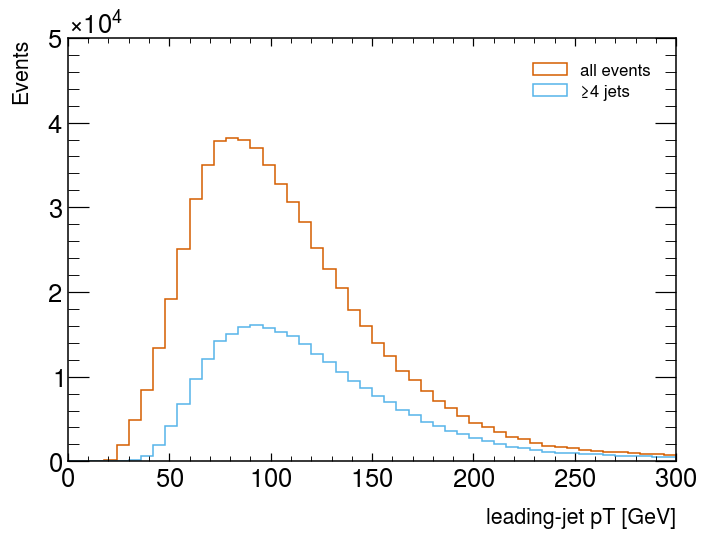

In [5]:
N_JETS = 4        # ✏️ try 3, 4, 5  (jet-multiplicity requirement)
LOG_Y  = False    # ✏️ stretch: True for a log y-axis

mask = ak.sum(events.jet_pt > 30, axis=1) >= N_JETS
lead_all    = ak.to_numpy(events.jet_pt[:, 0])
lead_passed = ak.to_numpy(events.jet_pt[mask][:, 0])

plt.hist(lead_all,    bins=50, range=(0, 300), histtype='step', label='all events')
plt.hist(lead_passed, bins=50, range=(0, 300), histtype='step', label=f'≥{N_JETS} jets')
if LOG_Y:
    plt.yscale('log')
plt.xlabel('leading-jet pT [GeV]'); plt.ylabel('Events'); plt.legend()